##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells. You can find more mark-down tips & tricks online, for example [here](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html) and [here](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet)

# EXAM03: Data Science Group Assignment - Iteration 2

**Group name:** A

**Student names & numbers:**
* [Damian van der Sluis] - [101360]
* [Achraf El Azzouzi] - [101674]
* [Saeed Alhasan] - [102384]

---

## 0. Iteration setup

**Import libraries**

In [2]:
# CODE CELL: import the necessary libraries for this iteration
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

**Load and merge datasets**

In [3]:
df_it1 = pd.read_csv("ships_inventory_iter1.csv")
df_it2 = pd.read_csv("ship_inspections_iter2.csv")

df = pd.merge(df_it1, df_it2, on="Ship_ID", how="left")

In [4]:
df

,Ship_ID,Galactic_Credits,Model_Cycle,Ship_Manufacturer,Sector,Hull_Integrity,Reactor_Power,Propulsion_Type,Ship_Class
0,7316160254,4950,7505.0,Galactic Motors,Mon Cala Ocean Worlds,Critical,40.0,Ion Drive,Shuttle
1,7316115206,18999,7518.0,Galactic Motors,Thraxos Blockade,Pristine,120.0,Solar Sail,Shuttle
2,7315865657,4000,7486.0,Republic Aerospace,Indoumodo Sector,Critical,40.0,Ion Drive,Shuttle
3,7314772431,6495,7511.0,Nebula Industries,Pantora Moon,Pristine,40.0,Graviton Beam,Shuttle
4,7311539325,3995,7499.0,Corellian Engineering,Malastare Narrows,Critical,40.0,Hyperdrive,Shuttle
...,...,...,...,...,...,...,...,...,...
368809,7314422916,12997,7516.0,Independent Shipwrights,Onderon Wilds,Pristine,120.0,Ion Drive,Shuttle
368810,7310477656,19965,7508.0,General Mining Corp,Wyl Sector,Critical,80.0,Ion Drive,Hauler
368811,7302695121,45990,7518.0,Independent Shipwrights,Indoumodo Sector,Pristine,80.0,NaN,Corvette
368812,7306742082,2000,7494.0,Corellian Engineering,Kashyyyk Homeworld,Critical,240.0,Hyperdrive,Freighter


---

## 1. Business Understanding
*Rubric: LO 6.4D (Reflection on Process)*

### **Situation description**

*Describe the problem surrounding the safety inspections. Why is the current process (human estimation/gut feeling) a risk?*

De ruwe data voor deze iteratie komt uit meerdere, losse bestanden uit iteratie 1 en 2. Daardoor is de informatie in eerste instantie gefragmenteerd: relevante kenmerken van hetzelfde schip staan niet in één uniforme tabel.
Daarnaast bevat de data kwaliteitsproblemen zoals missende waarden (onder andere in `Propulsion_Type`, `Reactor_Power` en `Model_Cycle`), dubbele records en inconsistente benamingen bij fabrikanten.

Voor de business is dit een probleem omdat inspectiebeslissingen dan worden gebaseerd op onvolledige of tegenstrijdige informatie. Een extra risico is het ontbreken van een eenduidige, gestandaardiseerde rating voor `Hull_Integrity`. Als inspecteurs vooral op ervaring of “gut feeling” werken, ontstaan verschillen tussen personen en teams. Dat leidt tot inconsistente uitkomsten: een schip kan door de ene inspecteur als veilig en door de andere als risicovol worden beoordeeld. Voor de organisatie betekent dit hogere aansprakelijkheids- en reputatierisico’s.

### **Business objective(s)**

*Justify why a standardized, rule-based expert system is needed.*

Het businessdoel in iteratie 2 is om het inspectieproces van Nebula Brokerage te standaardiseren met een uitlegbaar, rule-based systeem dat de `Hull_Integrity` van schepen consistent classificeert als `Critical`, `Operational` of `Pristine`.
Hiermee wil de organisatie de afhankelijkheid van subjectieve “gut feeling” elimineren, inspectiebeslissingen tussen inspecteurs uniform maken en vooral veiligheidsrisico’s door foutieve beoordelingen van kritieke schepen verminderen.

### **Data mining goal(s)**

*Explain what type of modeling task this is and why.*

Dit is een supervised classificatieprobleem: we voorspellen de categorische doelvariabele `Hull_Integrity` met klassen zoals `Critical`, `Operational` en `Pristine`.
Het is classificatie en geen regressie, omdat de output uit discrete labels bestaat en niet uit numerieke waardes.

Voor iteratie 2 kiezen we bewust een handmatig rule-based model (if/elif/else), zodat de logica transparant en controleerbaar blijft en domeinkennis direct kan worden vertaald naar beslisregels.

### **Success criteria**

*Determine success criteria for this iteration*

Succes wordt bepaald op twee niveaus: datasetkwaliteit en modelprestatie.

Dataset-criteria

Gegevens uit iteratie 1 en 2 zijn correct samengevoegd op Ship_ID.
Kritieke velden voor modellering (`Hull_Integrity`, `Reactor_Power`, `Propulsion_Type`) zijn bruikbaar gemaakt via verantwoorde cleaning/imputatie.
Duplicaten en inconsistenties in categorische labels zijn aantoonbaar aangepakt.
De voorbereide dataset is reproduceerbaar en exporteerbaar voor de volgende iteratie.  

Model-criteria

Het rule-based model geeft voor elke observatie met bekende input een voorspelling.
De prestatie wordt geëvalueerd met ten minste accuracy, confusion matrix en class-level metrics (precision/recall).
Veiligheidsfocus: de recall voor Critical moet voldoende hoog zijn. De regels zijn inhoudelijk te verklaren vanuit de data-analyse.

---

## 2. Data Understanding
*Rubric: LO 7.3Q (Visuals) & LO 6.4C (Process)*

**Data exploration**

*Show the summary statistics and describe the new variables (e.g., Propulsion_Type, Reactor_Power, Hull_Integrity). Describe your findings.*

In deze sectie analyseren we welke variabelen bruikbaar zijn om `Hull_Integrity` later met handmatige classificatie regels te voorspellen.
We focussen op:
- Samenvattende statistieken
- Datakwaliteit (missende waarden + outliers)
- Patronen tussen `Reactor_Power`, `Propulsion_Type`, `Ship_Class` en `Hull_Integrity`

In [5]:
print("Dataset shape:", df.shape)
print("Kolommen:", list(df.columns))

info_df = pd.DataFrame({
    "Column": df.columns,
    "Non-Null Count": df.notnull().sum().values,
    "Missing": df.isnull().sum().values,
    "Dtype": df.dtypes.values
})
info_df["Missing_%"] = (info_df["Missing"] / len(df) * 100).round(2)
info_df = info_df.sort_values("Missing", ascending=False)

display(info_df)

Dataset shape: (368814, 9)
Kolommen: ['Ship_ID', 'Galactic_Credits', 'Model_Cycle', 'Ship_Manufacturer', 'Sector', 'Hull_Integrity', 'Reactor_Power', 'Propulsion_Type', 'Ship_Class']


,Column,Non-Null Count,Missing,Dtype,Missing_%
7,Propulsion_Type,312108,56706,str,15.38
6,Reactor_Power,339345,29469,float64,7.99
2,Model_Cycle,361408,7406,float64,2.01
0,Ship_ID,368814,0,int64,0.00
1,Galactic_Credits,368814,0,int64,0.00
4,Sector,368814,0,str,0.00
3,Ship_Manufacturer,368814,0,str,0.00
5,Hull_Integrity,368814,0,str,0.00
8,Ship_Class,368814,0,str,0.00


De output toont dat de dataset 368814 rijen en 9 kolommen bevat.  
De belangrijkste datakwaliteitsissues zitten in:
- `Propulsion_Type` mist ongeveer 15,4% waarden.
- `Reactor_Power` mist ongeveer 8% waarden.
- `Model_Cycle` mist ongeveer 2% waarden.

In [6]:
display(df.describe(include=[np.number]).T)

,count,mean,std,min,25%,50%,75%,max
Ship_ID,368814.0,7.311485e+09,4.381124e+06,7.301583e+09,7.308105e+09,7.312604e+09,7.315245e+09,7.317101e+09
Galactic_Credits,368814.0,1.945354e+04,1.554047e+04,5.010000e+02,7.950000e+03,1.599000e+04,2.799000e+04,7.777770e+05
Model_Cycle,361408.0,7.511265e+03,9.078571e+00,7.400000e+03,7.508000e+03,7.513000e+03,7.517000e+03,7.522000e+03
Reactor_Power,339345.0,7.159053e+01,4.464994e+01,3.000000e+01,4.000000e+01,6.000000e+01,8.000000e+01,3.600000e+02


De numerieke samenvatting laat de spreiding van onder andere `Galactic_Credits`, `Model_Cycle` en `Reactor_Power` zien.  
Voor deze iteratie is vooral `Reactor_Power` belangrijk: de spreiding en extreme waarden suggereren dat deze variabele een sterke kandidaat is voor beslisregels in het handmatige classificatiemodel.

In [7]:
display(df.describe(include=["object"]).T)

C:\Users\icanc\AppData\Local\Temp\ipykernel_14456\1308661061.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=["object"]).T)


,count,unique,top,freq
Ship_Manufacturer,368814,28,Independent Shipwrights,94444
Sector,368814,51,Calodan Expanse,42150
Hull_Integrity,368814,3,Operational,141464
Propulsion_Type,312108,8,Ion Drive,177607
Ship_Class,368814,8,Shuttle,125887


De categorische output bevestigt dat `Hull_Integrity` de doelvariabele is met drie klassen (`Critical`, `Operational`, `Pristine`).  
Daarnaast tonen `Propulsion_Type` en `Ship_Class` meerdere categorieën die inhoudelijk bruikbaar zijn om klassen van elkaar te onderscheiden.

In [8]:
print("Verdeling Hull_Integrity in aantallen:")
print(df["Hull_Integrity"].value_counts(dropna=False))

Verdeling Hull_Integrity in aantallen:
Hull_Integrity
Operational    141464
Critical       118654
Pristine       108696
Name: count, dtype: int64


De aantallen per `Hull_Integrity`-klasse laten zien hoe de data over de drie klassen verdeeld is.  
Deze verdeling is belangrijk voor de evaluatie: als een klasse duidelijk een kleiner aantal bevat, moet later extra aandacht gaan naar de recall van die klasse (niet alleen totale accuracy).

In [9]:
print("Verdeling Hull_Integrity in percentages:")
print((df["Hull_Integrity"].value_counts(normalize=True) * 100).round(2))

Verdeling Hull_Integrity in percentages:
Hull_Integrity
Operational    38.36
Critical       32.17
Pristine       29.47
Name: proportion, dtype: float64


Hier nogmaals de verdeling maar dan in percentages.

**Visualizations and patterns**

*Discover patterns in the data that will help you determine the inspection rules. Create visualizations that show the relationship between variables like Reactor_Power, Propulsion_Type, Ship_Class on one side, and the target variable Hull_Integrity on the other. Describe any hard rules you discover (e.g., relationships with dangerous reactors or advanced tech).*

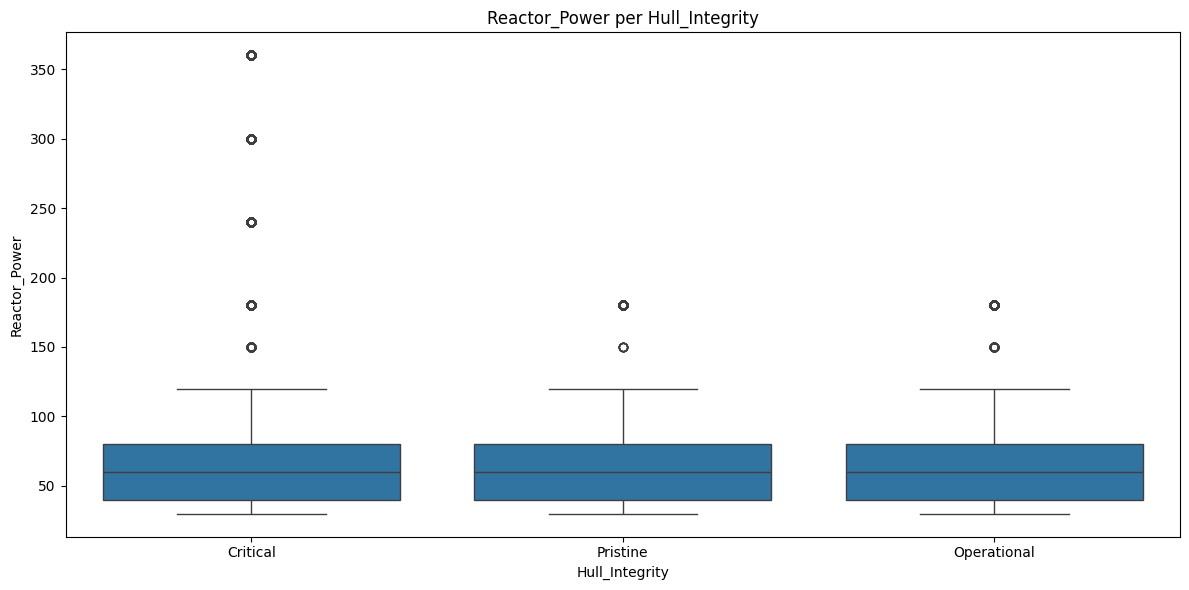

In [10]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Hull_Integrity", y="Reactor_Power")
plt.title("Reactor_Power per Hull_Integrity")
plt.tight_layout()
plt.show()

De boxplot toont duidelijke overlap tussen de drie klassen, maar ook zichtbare verschillen in uitschieters.
`Critical` bevat duidelijk meer/extremere hoge uitschieters dan de andere klassen.
Dit wijst erop dat hoge `Reactor_Power` waarden een risicosignaal kunnen zijn, maar dat `Reactor_Power` alleen waarschijnlijk niet voldoende is om alle klassen perfect te scheiden.

In [11]:
rp_stats = df.groupby("Hull_Integrity")["Reactor_Power"].agg(["count", "mean", "median"]).round(2)
display(rp_stats)

,count,mean,median
Hull_Integrity,,,
Critical,109248,80.97,60.0
Operational,130134,62.85,60.0
Pristine,99963,72.72,60.0


De tabel bevestigt dat hoewel de mediaan overal gelijk is (60.0), het gemiddelde sterk verschilt. Vooral bij Critical ligt dit gemiddelde veel hoger, wat duidt op een grotere spreiding naar boven toe. Door eerst te splitsen op Reactor_Power en daarna te verfijnen met deze klassen, vangen we die verschillen in verdeling effectief op in de regels voor classificatie.

In [12]:
rp = df["Reactor_Power"].dropna()

range_quantiles = pd.DataFrame({
    "Metric": ["Minimum", "Q1 (25%)", "Mediaan (50%)", "Q3 (75%)", "Maximum"],
    "Waarde": [
        rp.min(),
        rp.quantile(0.25),
        rp.median(),
        rp.quantile(0.75),
        rp.max()
    ]
})

range_quantiles["Waarde"] = range_quantiles["Waarde"].round(2)
display(range_quantiles)

,Metric,Waarde
0,Minimum,30.0
1,Q1 (25%),40.0
2,Mediaan (50%),60.0
3,Q3 (75%),80.0
4,Maximum,360.0


In deze tabel tonen we de spreiding van Reactor_Power met de minimum- en maximumwaarde en de belangrijkste quantiles (Q1, mediaan, Q3).  
Hiermee maken we expliciet hoe breed de verdeling is en of de hoogste waarden sterk afwijken van het grootste deel van de data.

Deze output gebruiken we als onderbouwing voor de outlier-analyse (IQR) in de volgende cel.

In [13]:
rp = df["Reactor_Power"].dropna()
q1 = rp.quantile(0.25)
q3 = rp.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df[(df["Reactor_Power"] < lower) | (df["Reactor_Power"] > upper)]

print("IQR lower bound:", round(lower, 2))
print("IQR upper bound:", round(upper, 2))
print("Aantal mogelijke outliers:", len(outliers))
print("Percentage mogelijke outliers:", round(len(outliers) / len(df) * 100, 2), "%")

IQR lower bound: -20.0
IQR upper bound: 140.0
Aantal mogelijke outliers: 20612
Percentage mogelijke outliers: 5.59 %


De IQR-analyse geeft een onder- en bovengrens voor normale waarden van `Reactor_Power` en toont hoeveel observaties daarbuiten vallen.  
Deze observaties labelen we als mogelijke outliers, maar we verwijderen ze in deze fase niet automatisch.

In [14]:
prop_tab = pd.crosstab(df["Propulsion_Type"], df["Hull_Integrity"], normalize="index")
prop_tab_pct = (prop_tab * 100).round(1).astype(str) + '%'
display(prop_tab_pct)

Hull_Integrity,Critical,Operational,Pristine
Propulsion_Type,,,
Antimatter,1.7%,0.9%,97.3%
Graviton Beam,2.3%,10.4%,87.3%
Hyperdrive,36.8%,38.2%,25.0%
Ion Drive,32.9%,40.4%,26.7%
Nuclear Pulse,42.8%,46.8%,10.4%
Plasma Hybrid,8.8%,54.1%,37.1%
Plasma Thruster,40.3%,35.6%,24.1%
Solar Sail,25.9%,37.3%,36.7%


De genormaliseerde tabel laat zien dat de verhouding `Critical/Operational/Pristine` sterk verschilt per `Propulsion_Type`.  
Voorbeeld uit de grafiek en tabel: sommige propulsion-types hebben een veel groter aandeel `Pristine`, terwijl andere types meer `Critical/Operational` bevatten.  
Dit maakt `Propulsion_Type` een sterke tweede voorwaarde in if-regels voor de classificatie.

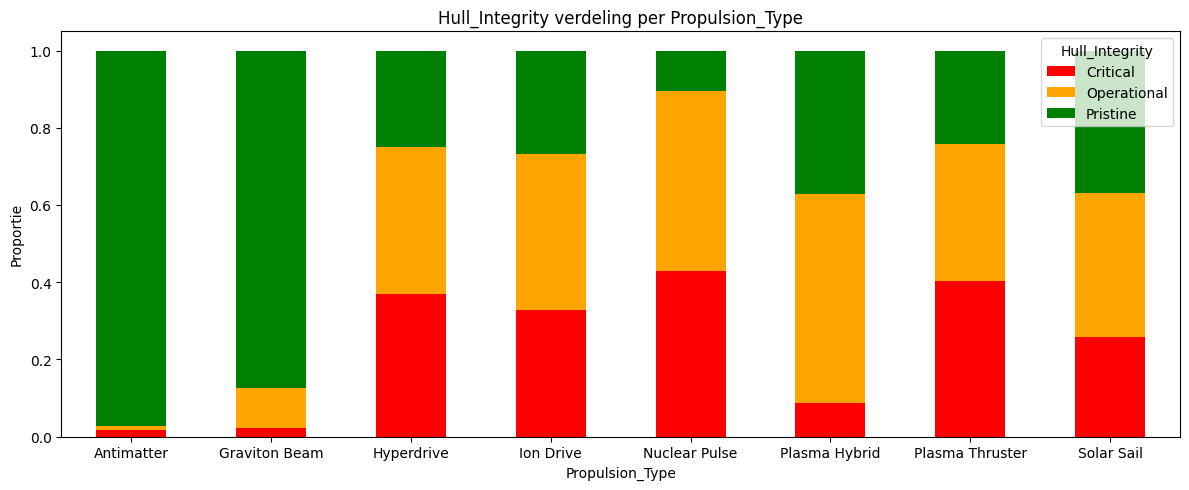

In [15]:
prop_tab.plot(kind="bar", stacked=True, figsize=(12, 6), color=["red", "orange", "green"])
plt.title("Hull_Integrity verdeling per Propulsion_Type")
plt.ylabel("Proportie")
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

De stacked bar chart bevestigt duidelijke patroonverschillen per propulsion-type:
- `Antimatter` en `Graviton Beam` zijn vooral `Pristine`
- `Nuclear Pulse` en `Plasma Thruster` hebben relatief veel `Critical`
- De rest heeft een relatief gelijkere verdeling.

`antimatter` en `Graviton beam` kunnen we dus gebruiken voor de classificatie regels.

In [16]:
class_tab = pd.crosstab(df["Ship_Class"], df["Hull_Integrity"], normalize="index")
class_tab_pct = (class_tab * 100).round(1).astype(str) + '%'
display(class_tab_pct)

Hull_Integrity,Critical,Operational,Pristine
Ship_Class,,,
Corvette,27.1%,42.4%,30.5%
Explorer,29.8%,39.2%,31.0%
Fighter,33.8%,30.6%,35.6%
Freighter,36.8%,34.4%,28.9%
Hauler,26.2%,31.7%,42.1%
Shuttle,36.5%,39.9%,23.7%
Speedster,47.4%,30.2%,22.4%
Troop Transport,30.4%,40.4%,29.2%


De verdeling per Ship_Class is grotendeels vergelijkbaar tussen de drie Hull_Integrity-klassen.
Daarom gebruiken we Ship_Class niet als regel voor de classificatie.

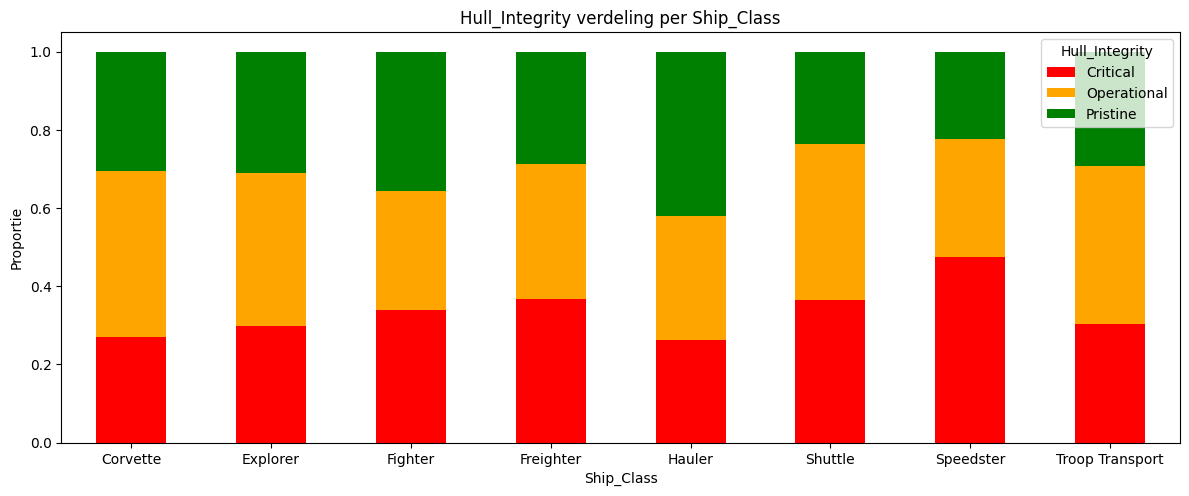

In [17]:
class_tab.plot(kind="bar", stacked=True, figsize=(12, 6), color=["red", "orange", "green"])
plt.title("Hull_Integrity verdeling per Ship_Class")
plt.ylabel("Proportie")
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

De visualisatie bevestigt dat de verdelingen per Ship_Class over het algemeen vrij vergelijkbaar zijn.  
Er zijn kleine verschillen (zoals een hoger aandeel Critical bij Speedster en een hoger aandeel Pristine bij Hauler), maar de klassen worden niet sterk van elkaar gescheiden op basis van Ship_Class alleen.

Conclusie:
Ship_Class gebruiken we niet als classificatieregel.

**Ship_Manufacturer vs Propulsion_Type**

Om missende waarden in Propulsion_Type onderbouwd in te vullen, onderzoeken we eerst of bepaalde manufacturers vooral met specifieke propulsion-types voorkomen.  
Als die relatie sterk is, is imputatie per manufacturer logischer dan 1 globale invulwaarde.

In [18]:
man_prop_pct = pd.crosstab(df["Ship_Manufacturer"], df["Propulsion_Type"], normalize="index", dropna=False) * 100

manufacturers = df["Ship_Manufacturer"].value_counts().index

display(man_prop_pct.loc[manufacturers].round(1).astype(str) + "%")

Propulsion_Type,Antimatter,Graviton Beam,Hyperdrive,Ion Drive,Nuclear Pulse,Plasma Hybrid,Plasma Thruster,Solar Sail,NaN
Ship_Manufacturer,,,,,,,,,
Independent Shipwrights,0.7%,0.0%,0.0%,73.5%,1.3%,1.0%,0.0%,7.9%,15.6%
Galactic Motors,0.1%,0.0%,0.0%,66.2%,11.8%,0.9%,0.0%,5.5%,15.5%
Corellian Engineering,0.0%,0.0%,84.8%,0.0%,0.0%,0.0%,0.0%,0.0%,15.2%
Kuat Drive Yards,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,84.8%,0.0%,15.2%
Hondo Systems,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,84.8%,15.2%
Jumpship Corp,0.0%,0.0%,0.0%,79.4%,0.8%,0.3%,0.0%,4.5%,15.0%
Republic Aerospace,0.0%,0.0%,0.0%,51.6%,28.1%,0.1%,0.0%,4.8%,15.4%
General Mining Corp,0.0%,0.0%,0.0%,65.3%,11.8%,0.1%,0.0%,6.7%,16.1%
Nebula Industries,0.0%,85.2%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,14.8%


De percentage-tabel laat zien dat de relatie tussen manufacturer en propulsion duidelijk niet willekeurig is.  
Voor meerdere manufacturers is er één dominante propulsion-vorm met een hoog aandeel (boven 70%), en bij enkele manufacturers is die dominantie volledig.

Dit is belangrijk voor de missende waarden in `Propulsion_Type`:
imputatie op basis van `Ship_Manufacturer` is inhoudelijk sterker dan één globale invulwaarde, omdat manufacturers duidelijk verschillende propulsion-profielen hebben.

<Figure size 2000x1000 with 0 Axes>

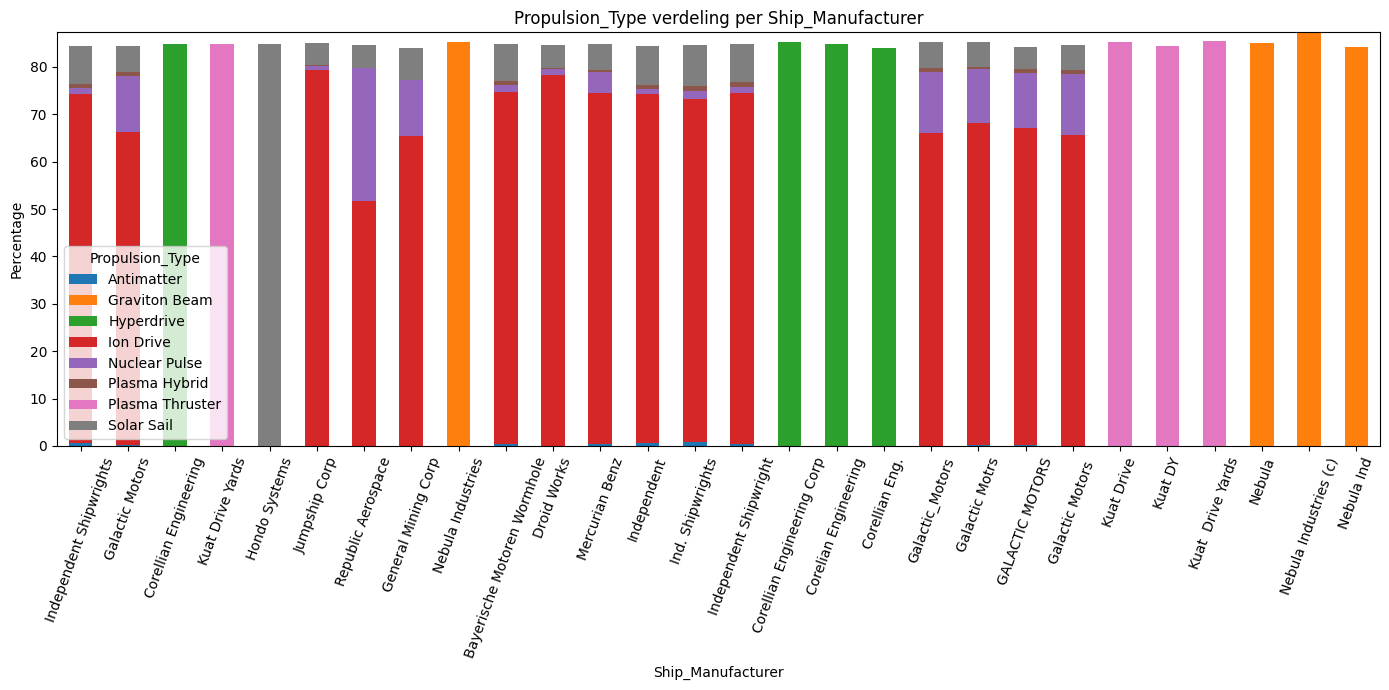

In [19]:
plt.figure(figsize=(20, 10))
(
    man_prop_pct.loc[manufacturers]
    .drop(columns=[c for c in man_prop_pct.columns if str(c) == "nan"], errors="ignore")
    .plot(kind="bar", stacked=True, figsize=(14, 7))
)
plt.title("Propulsion_Type verdeling per Ship_Manufacturer")
plt.ylabel("Percentage")
plt.xlabel("Ship_Manufacturer")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

De grafiek bevestigt het patroon uit de tabel: veel manufacturers hebben één kleur die het grootste deel van de staaf inneemt, wat wijst op een dominante propulsion keuze per manufacturer.

Conclusie:
1. Er is een sterke samenhang tussen Ship_Manufacturer en Propulsion_Type. Hierdoor kunnen we bij de missende waardes het `Propuslion_Type` betrouwbaar afleiden vanuit `Ship_Manufacturer`.
2. Voor dat we dat kunnen doen, moeten we wel eerst de namen van `Ship_manufacturer` standaardiseren.

**Data insights**  
*Samenvatting*  
Uit de analyse blijkt dat `Reactor_Power` en `Propulsion_Type` de meest bruikbare variabelen zijn voor classificatie van `Hull_Integrity`, omdat er een duidelijk verband zit tussen de de Hull_Integrity en de Reactor power en het propulsion type. Daarentegen zien we geen sterk verband terug tussen het `Ship_Class` en de Hull_Integrity, daarom gebruiken `Ship_Class` niet voor de classificatieregels.


Belangrijkste inzichten:
- `Reactor_Power` toont klasseverschillen en duidelijke extreme waarden
- `Propulsion_Type` geeft sterke verschillen in klasseverdeling
- `Ship_Class` gebruiken we NIET voor de classificatie.
- Datakwaliteit vraagt aandacht: missende waarden in `Propulsion_Type` en `Reactor_Power`, plus aanwezige outliers.
- Er is een duidelijke samenhang tussen `Ship_Manufacturer` en `Propulsion_Type`: veel manufacturers hebben een dominant `Propulsion-Type`. Daardoor is het invullen van missende `Propulsion_Type` waarden op basis van `Ship_Manufacturer` inhoudelijk beter dan één globale invulwaarde.
- Varianten in `Ship_Manufacturer` zoals verschillende schrijfwijzen van dezelfde fabrikant moeten eerst worden gestandaardiseerd.

Conclusie:  
In Modeling maken we een handmatige classifier. We gebruiken `Reactor_Power` als belangrijkste regel en `Propulsion_Type` als extra verfijning. Ship_Class nemen we niet mee, omdat die minder onderscheid maakt. Missende `Propulsion_Type` vullen we in via S`hip_Manufacturer`, nadat de verschillende schrijfwijzen van manufacturers eerst zijn gestandaardiseerd.

**Data quality**

In [20]:
total_duplicates = df.duplicated().sum()
shipid_duplicates = df.duplicated(subset=["Ship_ID"]).sum()

print("Totaal aantal duplicaten", total_duplicates)
print("Duplicaten op Ship_ID:", shipid_duplicates)

Totaal aantal duplicaten 500
Duplicaten op Ship_ID: 500


In [21]:
cat_cols = ["Ship_Manufacturer"]

for col in cat_cols:
    print(f"\n--- {col} ---")
    print("Unieke waarden:", df[col].nunique(dropna=True))
    
    manufacturer_count = df[col].value_counts(dropna=False)
    print(manufacturer_count)


--- Ship_Manufacturer ---
Unieke waarden: 28
Ship_Manufacturer
Independent Shipwrights        94444
Galactic Motors                57488
Corellian Engineering          44598
Kuat Drive Yards               27843
Hondo Systems                  19394
Jumpship Corp                  16803
Republic Aerospace             16191
General Mining Corp            15233
Nebula Industries              15125
Bayerische Motoren Wormhole    13327
Droid Works                    11685
Mercurian Benz                 10081
Independent                     3524
Ind. Shipwrights                3493
Independent Shipwright          3476
Corellian Engineering Corp      1656
Corelian Engineering            1650
Corellian Eng.                  1647
Galactic_Motors                 1636
Galactic Motrs                  1600
GALACTIC MOTORS                 1592
Galactic Motors                 1555
Kuat Drive                      1034
Kuat DY                         1030
Kuat  Drive Yards               1027
Nebula     

Op basis van de outputs zien we het volgende:

- Totaal aantal duplicaten: 500
- Duplicaten op Ship_ID: 500

Het totaal aantal duplicaten en duplicaten op Ship_ID zijn hetzelfde, dit wijst er op dat er records dubbelop in de dataset staan. In Data Preparation verwijderen we deze dubbele records om een onjuiste weergave in de analyse en modellering te voorkomen.

Typos en inconsistente labels:
Bij Ship_Manufacturer zien we duidelijke varianten die inhoudelijk waarschijnlijk hetzelfde betekenen, bijvoorbeeld:
- Independent Shipwrights
- Independent
- Ind. Shipwrights
- Independent Shipwright

Het gaat hier simpelweg om verschillende schrijfwijzen voor dezelfde groepen, niet om unieke nieuwe klassen. Bij het opschonen van de data standaardiseren we deze verschillende namen tot één uniforme naam.

---

## 3. Data Preparation
*Rubric: LO 6.4C (Data Science Steps)*

**Cleaning and preprocessing**
*Describe and justify how you resolve the missing values.*

In [3]:
# CODE CELL: Data cleaning, preprocessing
df_prep = df.copy()  # Werk op een kopie zodat het originele dataframe ongewijzigd blijft.

# Lege strings in categorische kolommen behandelen als missende waarden.
df_prep["Propulsion_Type"] = df_prep["Propulsion_Type"].replace("", pd.NA)

# Reactor_Power forceren naar numeriek; ongeldige waarden worden NaN.
df_prep["Reactor_Power"] = pd.to_numeric(df_prep["Reactor_Power"], errors="coerce")

# Missende waarden invullen.
# - Propulsion_Type (categorisch): modus (meest voorkomende categorie).
# - Reactor_Power (numeriek): mediaan (robuust voor outliers).
df_prep["Propulsion_Type"] = df_prep["Propulsion_Type"].fillna(df_prep["Propulsion_Type"].mode()[0])
df_prep["Reactor_Power"] = df_prep["Reactor_Power"].fillna(df_prep["Reactor_Power"].median())

# Validatie: controleer of de twee kernkolommen geen missende waarden meer bevatten.
print(df_prep[["Propulsion_Type", "Reactor_Power"]].isna().sum())

Propulsion_Type    0
Reactor_Power      0
dtype: int64


**Cleaning and preprocessing - toelichting en verantwoording**

In deze stap bereiden we de data voor op modellering op een reproduceerbare en controleerbare manier.

1. We starten met `df_prep = df.copy()` zodat de originele samengevoegde dataset (`df`) intact blijft.
2. Lege tekstvelden in `Propulsion_Type` zetten we om naar echte missende waarden (`NaN`) om ze consistent te kunnen behandelen.
3. `Reactor_Power` zetten we expliciet om naar numeriek (`pd.to_numeric(..., errors="coerce")`). Niet-numerieke of fout geformatteerde waarden worden daardoor ook als missend herkend.
4. Voor missende waarden gebruiken we variabele-specifieke imputatie:
   - `Propulsion_Type` (categorisch) vullen we met de **modus** (meest voorkomende categorie).
   - `Reactor_Power` (numeriek) vullen we met de **mediaan** om vertekening door outliers te beperken.
5. Tot slot controleren we expliciet of deze kolommen nog missende waarden bevatten.

**Waarom deze keuzes?**
- De modus is een logische baseline voor categorische data zonder extra aannames.
- De mediaan is stabieler dan het gemiddelde bij scheve verdelingen en uitschieters.
- We behouden zoveel mogelijk rijen voor training en evaluatie, in plaats van records vroegtijdig te verwijderen.

Deze aanpak is geschikt als eerste, robuuste baseline voor iteratie 2.

In [4]:
# OPTIONAL CODE CELL: Additional preprocessing steps

# Alleen rijen met bekende target behouden voor modeltraining/evaluatie.
df_model = df_prep.dropna(subset=["Hull_Integrity"]).copy()

# Selecteer alleen kolommen die direct relevant zijn voor de handmatige classifier.
model_cols = ["Ship_ID", "Ship_Class", "Propulsion_Type", "Reactor_Power", "Hull_Integrity"]
df_model = df_model[model_cols]

print(df_model.shape)
df_model.head()

(368814, 5)


,Ship_ID,Ship_Class,Propulsion_Type,Reactor_Power,Hull_Integrity
0,7316160254,Shuttle,Ion Drive,40.0,Critical
1,7316115206,Shuttle,Solar Sail,120.0,Pristine
2,7315865657,Shuttle,Ion Drive,40.0,Critical
3,7314772431,Shuttle,Graviton Beam,40.0,Pristine
4,7311539325,Shuttle,Hyperdrive,40.0,Critical


**Adjusting dataset (optional) - toelichting**

Voor modellering maken we een aparte dataset `df_model` met extra selectie-stappen:

1. We verwijderen records zonder `Hull_Integrity`, omdat deze targetwaarde nodig is om voorspellingen met werkelijkheid te vergelijken.
2. We beperken de dataset tot modelrelevante kolommen (`Ship_ID`, `Ship_Class`, `Propulsion_Type`, `Reactor_Power`, `Hull_Integrity`) om ruis te verminderen en de regels transparant te houden.

**Waarom dit nuttig is voor het model?**
- Het voorkomt dat rijen zonder label toch in evaluatie terechtkomen.
- Het maakt de dataset compacter, sneller te verwerken en beter uitlegbaar.
- De preprocessing voor modellering blijft gescheiden van de ruwe brondata, wat reproduceerbaarheid ondersteunt.

**Hoe werkt ons model?**

We gebruiken vier eigenschappen van een schip om de veiligheidsstatus Hull_Integrity in te schatten: het type aandrijving, de reactorkracht, de budget-credits van de eigenaar en hoe nieuw het model is.

Op basis van de data analyse uit hoofdstuk 2 hebben we een paar simpele, handmatige regels opgesteld:

1. **Gevaarlijke reactors (> 90 kracht) = Critical.**  
   Een te zware reactor is een enorm risico. Deze schepen bestempelen we direct als onveilig.
2. **Moderne aandrijving (Antimatter of Graviton Beam):**  
   - Heeft de eigenaar bovengemiddeld veel credits én een nieuwer schip? Dan is het schip waarschijnlijk perfect onderhouden (**Pristine**).
   - Is dat niet het geval, dan functioneert het in ieder geval redelijk (**Operational**).
3. **Oudere aandrijving (Nuclear Pulse of Plasma Thruster):**  
   - Heeft de eigenaar minder geld dan gemiddeld? Dan is er waarschijnlijk te weinig budget voor goed onderhoud, wat leidt tot een gevaarlijk schip (**Critical**).
   - Bij voldoende budget gaan we uit van de standaard status (**Operational**).
4. **De rest = Operational.**  
   Als een schip niet in de bovenstaande categorieën valt, is de veiligste aanname dat het gewoon normaal, gemiddeld functioneert.

We hebben deze logica rechttoe rechtaan geprogrammeerd met simpele `if`- en `else`-regels.

In [24]:
from sklearn.model_selection import train_test_split
eval_df = df.dropna(subset=['Hull_Integrity']).copy()

target = eval_df['Hull_Integrity']
features = eval_df[['Propulsion_Type', 'Reactor_Power', 'Galactic_Credits', 'Model_Cycle']]

feature_train, feature_test, target_train, target_test = train_test_split(features, target, test_size=0.25, random_state=42)

mean_credits = feature_train['Galactic_Credits'].mean()
mean_cycle = feature_train['Model_Cycle'].mean()

def manual_classification_model(row):
    if row['Reactor_Power'] > 90:
        return 'Critical'
        
    elif row['Propulsion_Type'] in ['Antimatter', 'Graviton Beam']:
        if row['Galactic_Credits'] >= mean_credits and row['Model_Cycle'] >= mean_cycle:
            return 'Pristine'
        return 'Operational'
            
    elif row['Propulsion_Type'] in ['Nuclear Pulse', 'Plasma Thruster']:
        if row['Galactic_Credits'] < mean_credits:
            return 'Critical'
        return 'Operational'
            
    return 'Operational'

# .apply(manual_classification_model, axis=1) is simpeler dan de lambda functie
feature_train['Prediction'] = feature_train.apply(manual_classification_model, axis=1)
feature_test['Prediction'] = feature_test.apply(manual_classification_model, axis=1)

df['Hull_Predicted'] = df.apply(manual_classification_model, axis=1)

Met de code hierboven laten we deze logische regels automatisch schip voor schip los op de hele dataset. Elk schip krijgt zo een voorspelde label. In de cel hieronder gaan we controleren hoe goed de aannames zijn.

**Testing and performance**
*Evaluate your manual rules. Calculate the metrics and generate a **confusion matrix** (visualize this using seaborn/matplotlib).*

Accuracy of train set: 0.4180253786920213
Accuracy of test set: 0.4174439286798837

Classification report (Test set):
              precision    recall  f1-score   support

    Critical       0.42      0.26      0.32     29534
 Operational       0.41      0.85      0.55     35286
    Pristine       1.00      0.03      0.05     27384

    accuracy                           0.42     92204
   macro avg       0.61      0.38      0.31     92204
weighted avg       0.59      0.42      0.33     92204



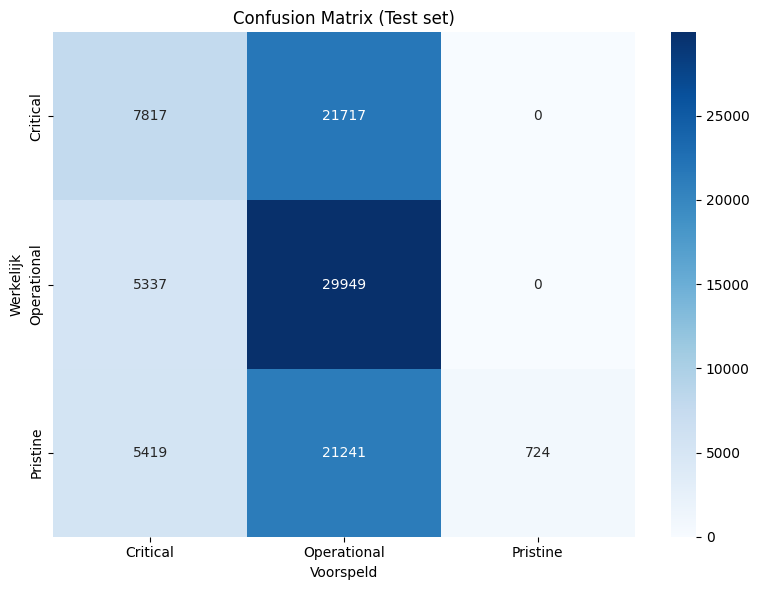

In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

print('Accuracy of train set:', accuracy_score(feature_train['Prediction'], target_train))
print('Accuracy of test set:', accuracy_score(feature_test['Prediction'], target_test))

print('\nClassification report (Test set):')
print(classification_report(target_test, feature_test['Prediction']))

labels = ["Critical", "Operational", "Pristine"]
cm = confusion_matrix(target_test, feature_test['Prediction'], labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.title("Confusion Matrix (Test set)")
plt.xlabel("Voorspeld")
plt.ylabel("Werkelijk")
plt.tight_layout()
plt.show()

**Conclusie**

Bovenaan zien we een *accuracy score*, een percentage dat simpelweg aangeeft in hoeveel procent van de gevallen we de staat van het schip goed hadden geraden. Dit meten we voor de 'Train-set' (om te kijken of het op de bekende data klopt) en, nog belangrijker, op de 'Test-set' (om te zien of onze theorie ook werkt voor *nieuwe* situaties).

Een algemeen percentage vertelt ons echter niet helemaal waar het fout gaat. Daarom kijken we ook naar een *confusion matrix* en een tabel met detailcijfers. Hiermee kunnen we precies zien voor welke specifieke groep ons model de mist in ging. Want let op: in de praktijk is het natuurlijk véél gevaarlijker om een enorm instabiel schip (`Critical`) onterecht door de keuring te laten komen als `Pristine`, dan andersom. Met deze inzichten kunnen we goed beoordelen of onze harde, handmatige regels wel betrouwbaar en veilig genoeg zijn voor de echte inspecties.

---

## 5. Evaluation
*Rubric: LO 6.4C (Results vs. Objectives)*

**Assessment against succes criteria** 
*How well does your manual model identify 'Critical' or 'Pristine' ships? Did you meet the goals set in the Business Understanding?*

**Key findings and limitations**
*What are the limitations of a manual, hard-rule-based system? Why might a machine Learning model be better in the next iteration?*

Use [pandas' to_csv](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) to export your cleaned and merged dataset for the next iteration. 

---

## 6 Personal Contribution
*Rubric: LO 7.3P (Equal Contribution)*

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Damian van der Sluis | ... | ... |
| Saeed Alhasan | ... | . |
| Achraf El Azzouzi | *Hoofdstuk 1 en 2* | Ik heb geleerd hoe belangrijk het is om data eerst goed te begrijpen met statistieken en visualisaties, omdat die inzichten direct bepalen welke variabelen bruikbaar zijn voor classificatieregels en hoe we bepalen welke missende waarden verantwoord invullen. |